## Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import ast
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("Bibliothèques importées avec succès")

Bibliothèques importées avec succès


## Configuration des styles de visualisation

In [2]:
# Configuration des styles pour les visualisations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Couleurs pour les différentes sources
colors = {'France Travail': '#1f77b4', 'LinkedIn': '#ff7f0e'}

print("Styles configurés")

Styles configurés


## Chargement des données France Travail

In [ ]:
# Chargement du fichier France Travail
try:
    df_ft = pd.read_csv('data/processed/offres_it_ciblees_france_travail.csv')
    print(f"France Travail : {df_ft.shape[0]} offres, {df_ft.shape[1]} colonnes")
    print("\nColonnes disponibles :")
    print(df_ft.columns.tolist())
except FileNotFoundError:
    print(" Fichier France Travail non trouvé")
    df_ft = pd.DataFrame()

France Travail : 5077 offres, 14 colonnes

Colonnes disponibles :
['intitule_poste', 'nom_entreprise', 'ville_region', 'date_publication', 'type_contrat', 'experience_demandee', 'niveau_seniorite', 'description_poste', 'source_offre', 'teletravail', 'competences_mentionnees', 'fourchette_salaire', 'metier_recherche', 'id_offre']


## Chargement des données LinkedIn

In [ ]:
# Chargement du fichier LinkedIn
try:
    df_li = pd.read_csv('data/processed/offres_it_france_linkedin.csv')
    print(f"LinkedIn : {df_li.shape[0]} offres, {df_li.shape[1]} colonnes")
    print("\nColonnes disponibles :")
    print(df_li.columns.tolist())
except FileNotFoundError:
    print(" Fichier LinkedIn non trouvé")
    df_li = pd.DataFrame()

LinkedIn : 319 offres, 14 colonnes

Colonnes disponibles :
['id_offre', 'intitule_poste', 'nom_entreprise', 'ville_region', 'date_publication', 'type_contrat', 'experience_demandee', 'niveau_seniorite', 'description_poste', 'source_offre', 'teletravail', 'competences_mentionnees', 'fourchette_salaire', 'metier_recherche']


## Exploration initiale France Travail

In [17]:
print(" EXPLORATION INITIALE - FRANCE TRAVAIL")
print("=" * 50)

if not df_ft.empty:
    print(f"Dimensions : {df_ft.shape}")
    print(f"\nTypes de données :")
    print(df_ft.dtypes)
    print(f"\nValeurs manquantes :")
    print(df_ft.isnull().sum())
    print(f"\nAperçu des données :")
    display(df_ft.head(3))
else:
    print("Aucune donnée France Travail disponible")

 EXPLORATION INITIALE - FRANCE TRAVAIL
Dimensions : (5077, 14)

Types de données :
intitule_poste             object
nom_entreprise             object
ville_region               object
date_publication           object
type_contrat               object
experience_demandee        object
niveau_seniorite           object
description_poste          object
source_offre               object
teletravail                object
competences_mentionnees    object
fourchette_salaire         object
metier_recherche           object
id_offre                   object
dtype: object

Valeurs manquantes :
intitule_poste                0
nom_entreprise             1489
ville_region                  0
date_publication              0
type_contrat                  0
experience_demandee          10
niveau_seniorite              0
description_poste             0
source_offre                  0
teletravail                   0
competences_mentionnees       0
fourchette_salaire         2725
metier_recherche     

,intitule_poste,nom_entreprise,ville_region,date_publication,type_contrat,experience_demandee,niveau_seniorite,description_poste,source_offre,teletravail,competences_mentionnees,fourchette_salaire,metier_recherche,id_offre
0,Développeur C embarqué - Domaine des systèmes ...,SILKHOM,91 - Massy,2025-11-25T18:04:23.304Z,CDI,Débutant accepté,Junior,Notre client est spécialisé dans le domaine de...,https://candidat.francetravail.fr/offres/reche...,Non,"python, c++, c, r, linux, ai",Annuel de 40000.0 Euros à 50000.0 Euros sur 12...,développeur,200TVZN
1,Developpeur Fullstack Java / Angular H/F (H/F),STEP UP NANTES,44 - NANTES,2025-11-25T15:37:12.545Z,CDI,4 An(s),Confirmé,Missions\nDéveloppement : participer à la conc...,https://candidat.francetravail.fr/offres/reche...,Non,"java, c, r, angular, vue, kubernetes, agile, s...",Annuel de 35000.0 Euros à 50000.0 Euros sur 12...,développeur,200TQGK
2,Développeur / Développeuse full-stack (H/F),TECH IN FRANCE,75 - Paris (Dept.),2025-11-25T15:06:02.674Z,CDI,5 An(s),Non spécifié,Tech In France éditeur de logiciels applicatif...,https://candidat.francetravail.fr/offres/reche...,Oui,"java, javascript, c, r, css, tailwind, laravel...",Mensuel de 2000.00 Euros à 2800.00 Euros sur 1...,développeur,200TPBM


## Exploration initiale LinkedIn

In [18]:
print(" EXPLORATION INITIALE - LINKEDIN")
print("=" * 50)

if not df_li.empty:
    print(f"Dimensions : {df_li.shape}")
    print(f"\nTypes de données :")
    print(df_li.dtypes)
    print(f"\nValeurs manquantes :")
    print(df_li.isnull().sum())
    print(f"\nAperçu des données :")
    display(df_li.head(3))
else:
    print("Aucune donnée LinkedIn disponible")

 EXPLORATION INITIALE - LINKEDIN
Dimensions : (319, 14)

Types de données :
id_offre                   object
intitule_poste             object
nom_entreprise             object
ville_region               object
date_publication           object
type_contrat               object
experience_demandee        object
niveau_seniorite           object
description_poste          object
source_offre               object
teletravail                object
competences_mentionnees    object
fourchette_salaire         object
metier_recherche           object
dtype: object

Valeurs manquantes :
id_offre                   0
intitule_poste             0
nom_entreprise             0
ville_region               0
date_publication           0
type_contrat               0
experience_demandee        0
niveau_seniorite           0
description_poste          0
source_offre               0
teletravail                0
competences_mentionnees    1
fourchette_salaire         0
metier_recherche           0
dtype:

,id_offre,intitule_poste,nom_entreprise,ville_region,date_publication,type_contrat,experience_demandee,niveau_seniorite,description_poste,source_offre,teletravail,competences_mentionnees,fourchette_salaire,metier_recherche
0,linkedin_6657791230523982292,Candidature spontanée,TENERGIE,Fuveau,2025-11-26T11:53:31.844001,CDI,5+ ans,Senior,Vous êtes convaincu que les énergies renouvela...,https://fr.linkedin.com/jobs/view/candidature-...,Non,"c, ai, soc",Annuel de 50000 Euros à 65000 Euros sur 12.0 mois,développeur
1,linkedin_-7702347840892000358,Développeur ou développeuse Backend,LACROIX,Cesson-Sévigné,2025-11-26T11:53:32.730414,CDI,5+ ans,Senior,"LACROIX est un groupe industriel, internationa...",https://fr.linkedin.com/jobs/view/d%C3%A9velop...,Non,"redis, c, aws, soc, spring, sécurité, java, ai...",Annuel de 50000 Euros à 65000 Euros sur 12.0 mois,développeur
2,linkedin_-7278503271929244851,DEVELOPPEUR-SE (F/H),Ministère de la Justice,75 - Paris,2025-11-26T11:53:33.723398,CDI,0-2 ans,Non spécifié,La Direction du numérique recrute : rejoignez-...,https://fr.linkedin.com/jobs/view/developpeur-...,Oui,"javascript, sécurité, css, postgresql, docker,...",Annuel de 48299 Euros à 63249 Euros sur 12.0 mois,développeur


## Nettoyage et préparation des données

In [19]:
print(" NETTOYAGE ET PRÉPARATION DES DONNÉES")
print("=" * 50)

def clean_data(df, source_name):
    """Fonction de nettoyage des données"""
    if df.empty:
        return df

    # Créer une colonne source
    df['source'] = source_name

    # Nettoyer les colonnes de compétences (si string, convertir en liste)
    if 'competences_mentionnees' in df.columns:
        df['competences_mentionnees'] = df['competences_mentionnees'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else []
        )

    # Extraire le salaire minimum et maximum
    if 'fourchette_salaire' in df.columns:
        df['salaire_min'] = df['fourchette_salaire'].str.extract(r'de (\d+)\.?\d* Euros')
        df['salaire_max'] = df['fourchette_salaire'].str.extract(r'à (\d+)\.?\d* Euros')

        # Convertir en numérique
        df['salaire_min'] = pd.to_numeric(df['salaire_min'], errors='coerce')
        df['salaire_max'] = pd.to_numeric(df['salaire_max'], errors='coerce')

    return df

# Appliquer le nettoyage
df_ft_clean = clean_data(df_ft, 'France Travail')
df_li_clean = clean_data(df_li, 'LinkedIn')

print("✅ Données nettoyées avec succès")

 NETTOYAGE ET PRÉPARATION DES DONNÉES
✅ Données nettoyées avec succès


## Fusion des données pour analyse comparative

In [20]:
print("FUSION DES DONNÉES POUR ANALYSE COMPARATIVE")
print("=" * 50)

# Fusionner les deux datasets
if not df_ft_clean.empty and not df_li_clean.empty:
    df_combined = pd.concat([df_ft_clean, df_li_clean], ignore_index=True)
    print(f"Dataset combiné : {df_combined.shape[0]} offres au total")

    # Distribution par source
    source_dist = df_combined['source'].value_counts()
    print(f"\nDistribution par source :")
    for source, count in source_dist.items():
        print(f"  {source} : {count} offres ({count/len(df_combined)*100:.1f}%)")
else:
    df_combined = df_ft_clean if not df_ft_clean.empty else df_li_clean
    print(f"Dataset unique : {len(df_combined)} offres de {df_combined['source'].iloc[0]}")

display(df_combined[['intitule_poste', 'nom_entreprise', 'ville_region', 'source']].head(5))

FUSION DES DONNÉES POUR ANALYSE COMPARATIVE
Dataset combiné : 5396 offres au total

Distribution par source :
  France Travail : 5077 offres (94.1%)
  LinkedIn : 319 offres (5.9%)


,intitule_poste,nom_entreprise,ville_region,source
0,Développeur C embarqué - Domaine des systèmes ...,SILKHOM,91 - Massy,France Travail
1,Developpeur Fullstack Java / Angular H/F (H/F),STEP UP NANTES,44 - NANTES,France Travail
2,Développeur / Développeuse full-stack (H/F),TECH IN FRANCE,75 - Paris (Dept.),France Travail
3,Développeur Sénior C++ Linux embarqué (H/F),EVBOX,33 - LEOGNAN,France Travail
4,Java Développeur DevOps (H/F),EVER TEAM SOFTWARE,69 - LYON 04,France Travail


## Analyse des métiers recherchés

ANALYSE DES MÉTIERS RECHERCHÉS


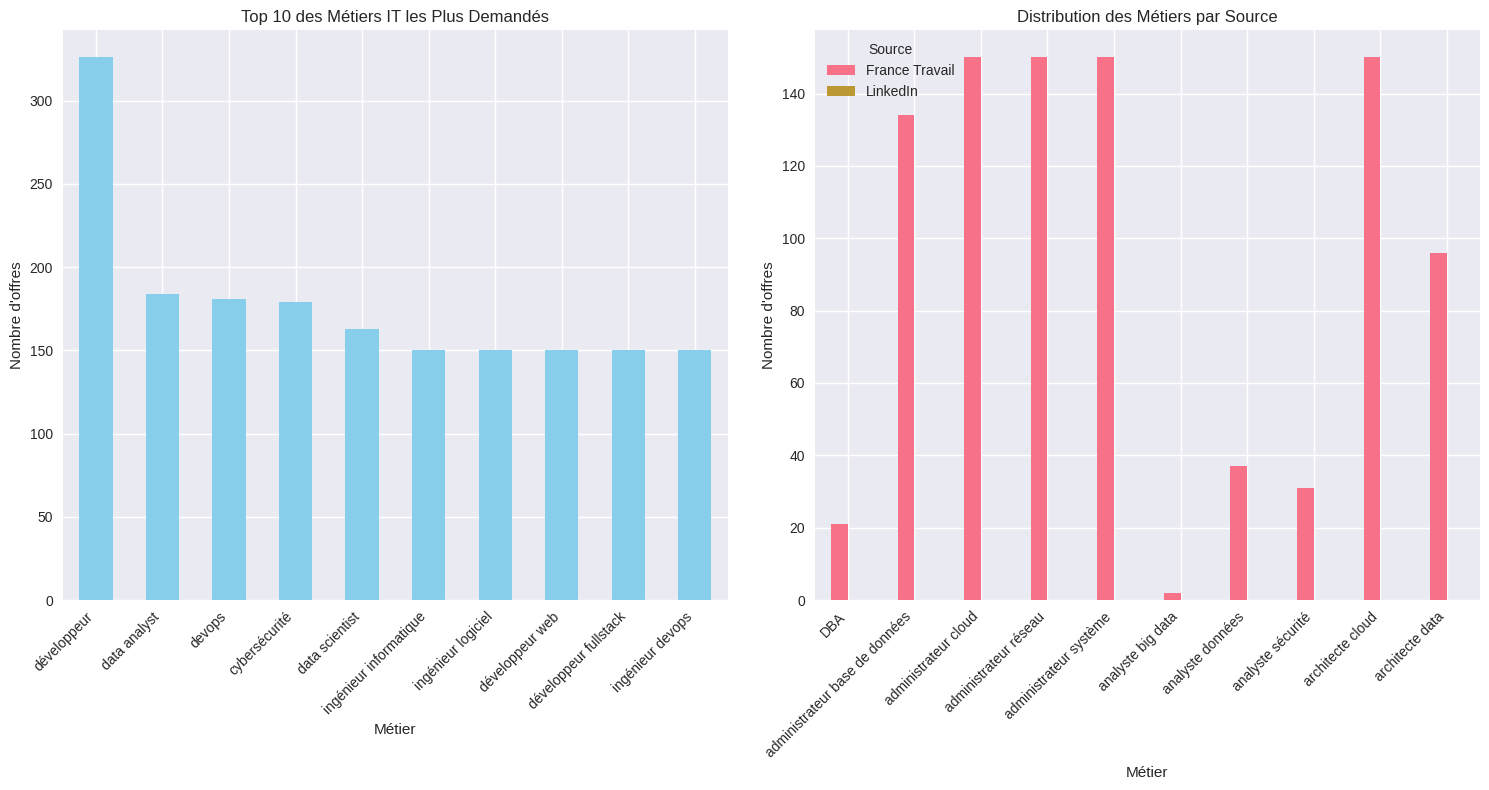


📈 Métiers les plus demandés :
  développeur : 326 offres
  data analyst : 184 offres
  devops : 181 offres
  cybersécurité : 179 offres
  data scientist : 163 offres
  ingénieur informatique : 150 offres
  ingénieur logiciel : 150 offres
  développeur web : 150 offres
  développeur fullstack : 150 offres
  ingénieur devops : 150 offres


In [21]:
print("ANALYSE DES MÉTIERS RECHERCHÉS")
print("=" * 50)

plt.figure(figsize=(15, 8))

if 'metier_recherche' in df_combined.columns:
    # Top 10 des métiers les plus demandés
    metiers_count = df_combined['metier_recherche'].value_counts().head(10)

    plt.subplot(1, 2, 1)
    metiers_count.plot(kind='bar', color='skyblue')
    plt.title('Top 10 des Métiers IT les Plus Demandés')
    plt.xlabel('Métier')
    plt.ylabel('Nombre d\'offres')
    plt.xticks(rotation=45, ha='right')

    # Distribution par source
    plt.subplot(1, 2, 2)
    if 'source' in df_combined.columns:
        metier_source = pd.crosstab(df_combined['metier_recherche'], df_combined['source']).head(10)
        metier_source.plot(kind='bar', ax=plt.gca())
        plt.title('Distribution des Métiers par Source')
        plt.xlabel('Métier')
        plt.ylabel('Nombre d\'offres')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Source')

    plt.tight_layout()
    plt.show()

    print(f"\n📈 Métiers les plus demandés :")
    for metier, count in metiers_count.items():
        print(f"  {metier} : {count} offres")
else:
    print("❌ Colonne 'metier_recherche' non disponible")

## Analyse des niveaux de séniorité

 ANALYSE DES NIVEAUX DE SÉNIORITÉ


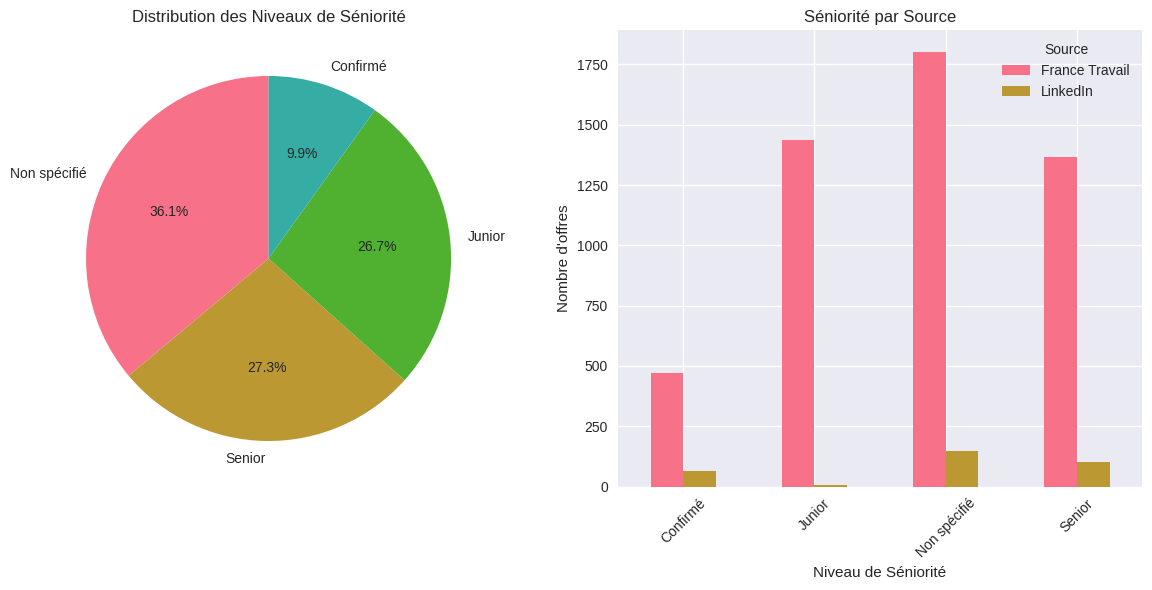


📊 Distribution des niveaux :
  Non spécifié : 1948 offres (36.1%)
  Senior : 1472 offres (27.3%)
  Junior : 1442 offres (26.7%)
  Confirmé : 534 offres (9.9%)


In [22]:
print(" ANALYSE DES NIVEAUX DE SÉNIORITÉ")
print("=" * 50)

if 'niveau_seniorite' in df_combined.columns:
    plt.figure(figsize=(12, 6))

    # Distribution globale
    plt.subplot(1, 2, 1)
    seniorite_count = df_combined['niveau_seniorite'].value_counts()
    plt.pie(seniorite_count.values, labels=seniorite_count.index, autopct='%1.1f%%', startangle=90)
    plt.title('Distribution des Niveaux de Séniorité')

    # Distribution par source
    plt.subplot(1, 2, 2)
    if 'source' in df_combined.columns:
        seniorite_source = pd.crosstab(df_combined['niveau_seniorite'], df_combined['source'])
        seniorite_source.plot(kind='bar', ax=plt.gca())
        plt.title('Séniorité par Source')
        plt.xlabel('Niveau de Séniorité')
        plt.ylabel('Nombre d\'offres')
        plt.xticks(rotation=45)
        plt.legend(title='Source')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Distribution des niveaux :")
    for niveau, count in seniorite_count.items():
        print(f"  {niveau} : {count} offres ({count/len(df_combined)*100:.1f}%)")
else:
    print("❌ Colonne 'niveau_seniorite' non disponible")

## Analyse géographique

 ANALYSE GÉOGRAPHIQUE


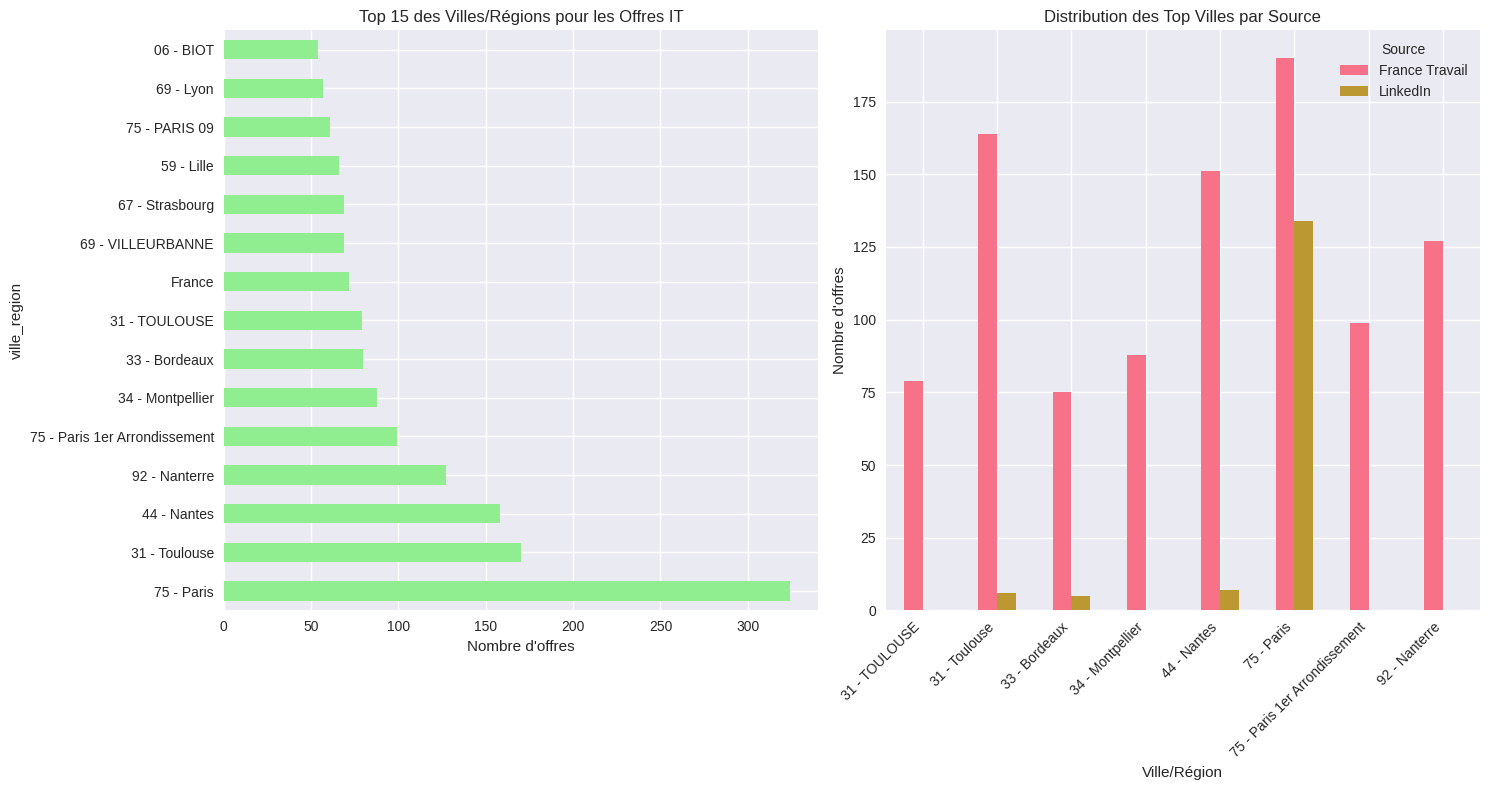


 Top 10 des localisations :
  1. 75 - Paris : 324 offres
  2. 31 - Toulouse : 170 offres
  3. 44 - Nantes : 158 offres
  4. 92 - Nanterre : 127 offres
  5. 75 - Paris 1er Arrondissement : 99 offres
  6. 34 - Montpellier : 88 offres
  7. 33 - Bordeaux : 80 offres
  8. 31 - TOULOUSE : 79 offres
  9. France : 72 offres
  10. 69 - VILLEURBANNE : 69 offres


In [24]:
print(" ANALYSE GÉOGRAPHIQUE")
print("=" * 50)

if 'ville_region' in df_combined.columns:
    # Top 15 des villes/régions
    villes_count = df_combined['ville_region'].value_counts().head(15)

    plt.figure(figsize=(15, 8))

    plt.subplot(1, 2, 1)
    villes_count.plot(kind='barh', color='lightgreen')
    plt.title('Top 15 des Villes/Régions pour les Offres IT')
    plt.xlabel('Nombre d\'offres')

    plt.subplot(1, 2, 2)
    # Distribution par source pour les top villes
    top_villes = villes_count.head(8).index
    df_top_villes = df_combined[df_combined['ville_region'].isin(top_villes)]

    if 'source' in df_combined.columns:
        ville_source = pd.crosstab(df_top_villes['ville_region'], df_top_villes['source'])
        ville_source.plot(kind='bar', ax=plt.gca())
        plt.title('Distribution des Top Villes par Source')
        plt.xlabel('Ville/Région')
        plt.ylabel('Nombre d\'offres')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Source')

    plt.tight_layout()
    plt.show()

    print(f"\n Top 10 des localisations :")
    for i, (ville, count) in enumerate(villes_count.head(10).items(), 1):
        print(f"  {i}. {ville} : {count} offres")
else:
    print("❌ Colonne 'ville_region' non disponible")

## Analyse des types de contrat

 ANALYSE DES TYPES DE CONTRAT


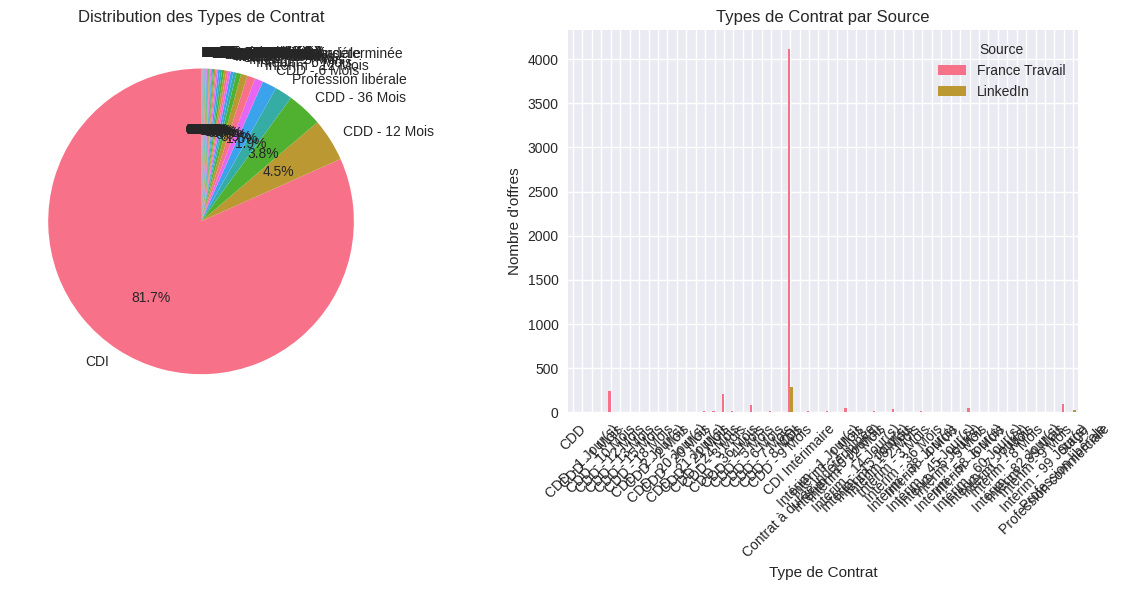


📄 Types de contrat :
  CDI : 4408 offres
  CDD - 12 Mois : 245 offres
  CDD - 36 Mois : 203 offres
  Profession libérale : 100 offres
  CDD - 6 Mois : 82 offres
  Intérim - 12 Mois : 47 offres
  Intérim - 6 Mois : 46 offres
  Intérim - 3 Mois : 37 offres
  Stage : 27 offres
  Intérim - 4 Mois : 17 offres
  Intérim - 18 Mois : 16 offres
  CDD - 4 Mois : 13 offres
  CDD - 8 Mois : 12 offres
  CDD - 3 Mois : 12 offres
  Intérim - 1 Mois : 12 offres
  CDD - 24 Mois : 11 offres
  Contrat à durée indéterminée : 11 offres
  Intérim - 2 Mois : 9 offres
  CDD - 10 Mois : 7 offres
  CDD - 9 Mois : 7 offres
  CDD - 1 Mois : 6 offres
  CDD - 2 Mois : 5 offres
  CDD - 18 Mois : 5 offres
  Profession commerciale : 5 offres
  CDD - 13 Mois : 4 offres
  CDD - 21 Mois : 4 offres
  CDD : 4 offres
  Intérim - 8 Mois : 4 offres
  Intérim - 9 Mois : 4 offres
  CDD - 5 Mois : 4 offres
  Intérim - 10 Jour(s) : 2 offres
  CDD - 20 Mois : 2 offres
  Intérim - 36 Mois : 2 offres
  Intérim - 38 Jour(s) : 2 offr

In [25]:
print(" ANALYSE DES TYPES DE CONTRAT")
print("=" * 50)

if 'type_contrat' in df_combined.columns:
    contrat_count = df_combined['type_contrat'].value_counts()

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.pie(contrat_count.values, labels=contrat_count.index, autopct='%1.1f%%', startangle=90)
    plt.title('Distribution des Types de Contrat')

    plt.subplot(1, 2, 2)
    if 'source' in df_combined.columns:
        contrat_source = pd.crosstab(df_combined['type_contrat'], df_combined['source'])
        contrat_source.plot(kind='bar', ax=plt.gca())
        plt.title('Types de Contrat par Source')
        plt.xlabel('Type de Contrat')
        plt.ylabel('Nombre d\'offres')
        plt.xticks(rotation=45)
        plt.legend(title='Source')

    plt.tight_layout()
    plt.show()

    print(f"\n📄 Types de contrat :")
    for contrat, count in contrat_count.items():
        print(f"  {contrat} : {count} offres")
else:
    print("❌ Colonne 'type_contrat' non disponible")

## Analyse du télétravail

 ANALYSE DU TÉLÉTRAVAIL


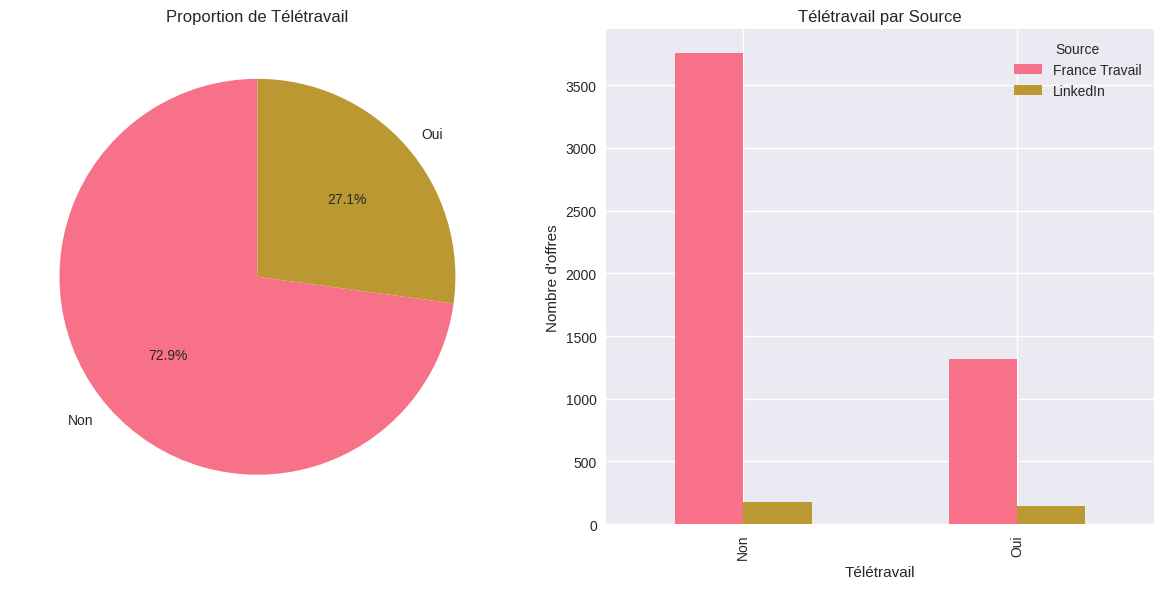


💻 Télétravail :
  Non : 3931 offres (72.9%)
  Oui : 1465 offres (27.1%)


In [26]:
print(" ANALYSE DU TÉLÉTRAVAIL")
print("=" * 50)

if 'teletravail' in df_combined.columns:
    teletravail_count = df_combined['teletravail'].value_counts()

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.pie(teletravail_count.values, labels=teletravail_count.index, autopct='%1.1f%%', startangle=90)
    plt.title('Proportion de Télétravail')

    plt.subplot(1, 2, 2)
    if 'source' in df_combined.columns:
        teletravail_source = pd.crosstab(df_combined['teletravail'], df_combined['source'])
        teletravail_source.plot(kind='bar', ax=plt.gca())
        plt.title('Télétravail par Source')
        plt.xlabel('Télétravail')
        plt.ylabel('Nombre d\'offres')
        plt.legend(title='Source')

    plt.tight_layout()
    plt.show()

    print(f"\n💻 Télétravail :")
    for mode, count in teletravail_count.items():
        print(f"  {mode} : {count} offres ({count/len(df_combined)*100:.1f}%)")
else:
    print("❌ Colonne 'teletravail' non disponible")

## Analyse des salaires

 ANALYSE DES SALAIRES


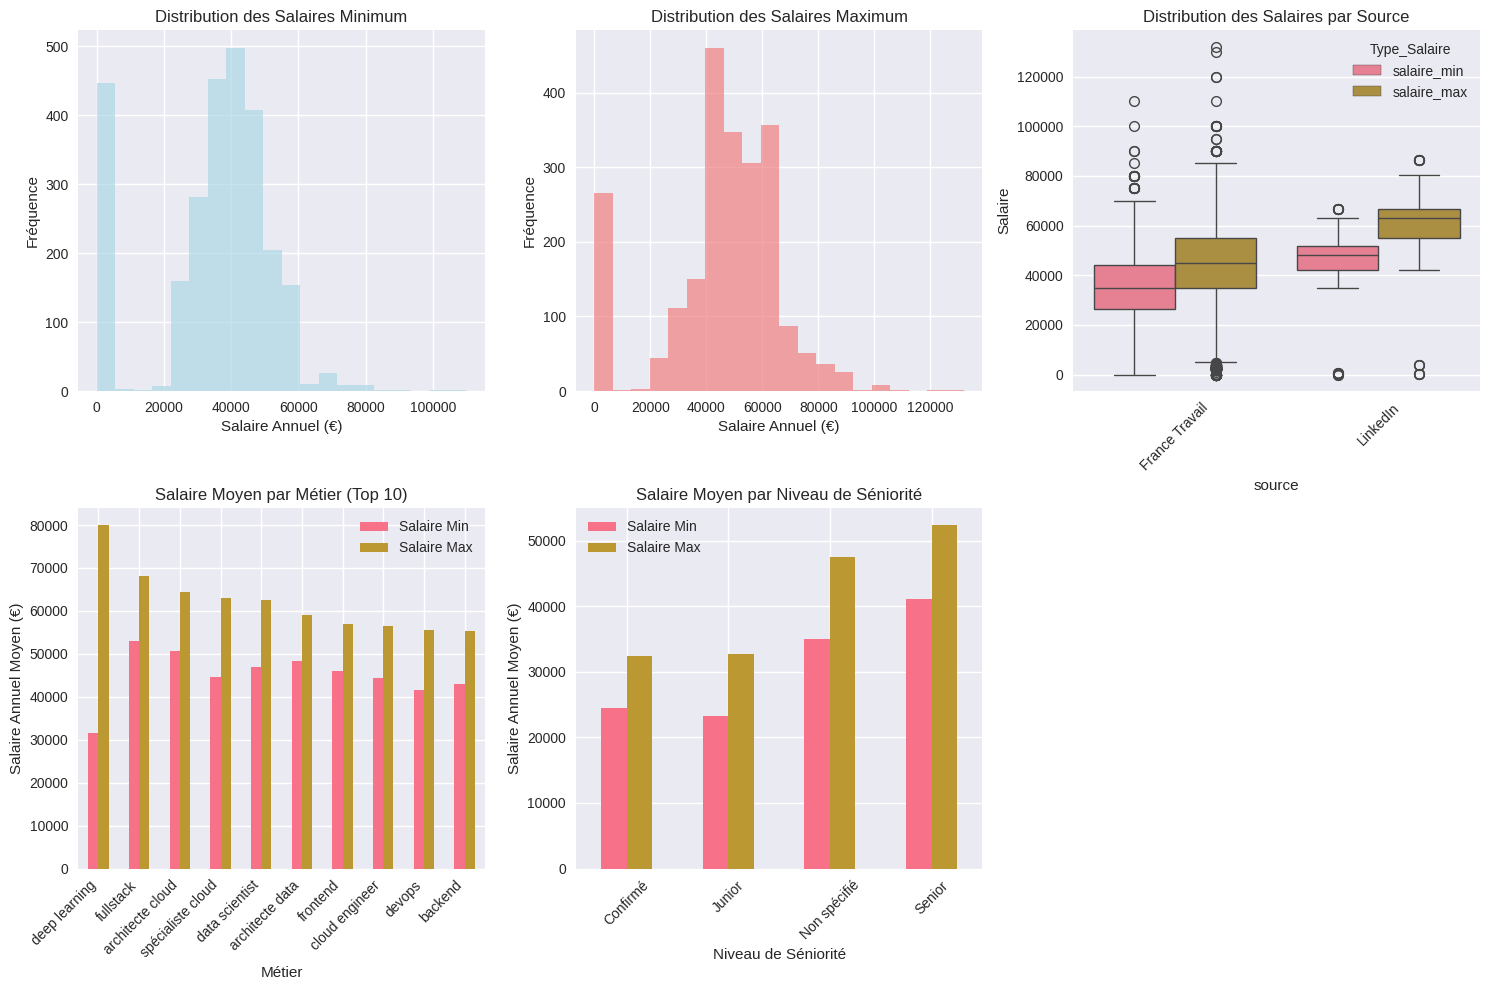


📊 Statistiques salariales :
         salaire_min    salaire_max
count    2671.000000    2261.000000
mean    34386.882815   45705.211411
std     17297.220237   20492.546555
min         0.000000       0.000000
25%     28500.000000   38000.000000
50%     38000.000000   49000.000000
75%     45000.000000   59799.000000
max    110000.000000  132000.000000

💡 Taux de complétion des données salariales : 49.5%


In [27]:
print(" ANALYSE DES SALAIRES")
print("=" * 50)

if 'salaire_min' in df_combined.columns and 'salaire_max' in df_combined.columns:
    # Statistiques descriptives
    salaire_stats = df_combined[['salaire_min', 'salaire_max']].describe()

    plt.figure(figsize=(15, 10))

    # Distribution des salaires minimum
    plt.subplot(2, 3, 1)
    plt.hist(df_combined['salaire_min'].dropna(), bins=20, alpha=0.7, color='lightblue')
    plt.title('Distribution des Salaires Minimum')
    plt.xlabel('Salaire Annuel (€)')
    plt.ylabel('Fréquence')

    # Distribution des salaires maximum
    plt.subplot(2, 3, 2)
    plt.hist(df_combined['salaire_max'].dropna(), bins=20, alpha=0.7, color='lightcoral')
    plt.title('Distribution des Salaires Maximum')
    plt.xlabel('Salaire Annuel (€)')
    plt.ylabel('Fréquence')

    # Boxplot par source
    plt.subplot(2, 3, 3)
    if 'source' in df_combined.columns:
        df_melted = df_combined[['salaire_min', 'salaire_max', 'source']].melt(
            id_vars=['source'],
            value_vars=['salaire_min', 'salaire_max'],
            var_name='Type_Salaire',
            value_name='Salaire'
        )
        sns.boxplot(data=df_melted.dropna(), x='source', y='Salaire', hue='Type_Salaire')
        plt.title('Distribution des Salaires par Source')
        plt.xticks(rotation=45)

    # Salaire moyen par métier (top 10)
    plt.subplot(2, 3, 4)
    if 'metier_recherche' in df_combined.columns:
        salaire_par_metier = df_combined.groupby('metier_recherche').agg({
            'salaire_min': 'mean',
            'salaire_max': 'mean'
        }).dropna().sort_values('salaire_max', ascending=False).head(10)

        salaire_par_metier.plot(kind='bar', ax=plt.gca())
        plt.title('Salaire Moyen par Métier (Top 10)')
        plt.xlabel('Métier')
        plt.ylabel('Salaire Annuel Moyen (€)')
        plt.xticks(rotation=45, ha='right')
        plt.legend(['Salaire Min', 'Salaire Max'])

    # Salaire par niveau de séniorité
    plt.subplot(2, 3, 5)
    if 'niveau_seniorite' in df_combined.columns:
        salaire_par_niveau = df_combined.groupby('niveau_seniorite').agg({
            'salaire_min': 'mean',
            'salaire_max': 'mean'
        }).dropna()

        salaire_par_niveau.plot(kind='bar', ax=plt.gca())
        plt.title('Salaire Moyen par Niveau de Séniorité')
        plt.xlabel('Niveau de Séniorité')
        plt.ylabel('Salaire Annuel Moyen (€)')
        plt.xticks(rotation=45)
        plt.legend(['Salaire Min', 'Salaire Max'])

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Statistiques salariales :")
    print(salaire_stats)

    # Taux de complétion des salaires
    salaire_completion = (df_combined['salaire_min'].notna().sum() / len(df_combined)) * 100
    print(f"\n💡 Taux de complétion des données salariales : {salaire_completion:.1f}%")
else:
    print("❌ Colonnes salariales non disponibles")

## Analyse temporelle

📅 ANALYSE TEMPORELLE


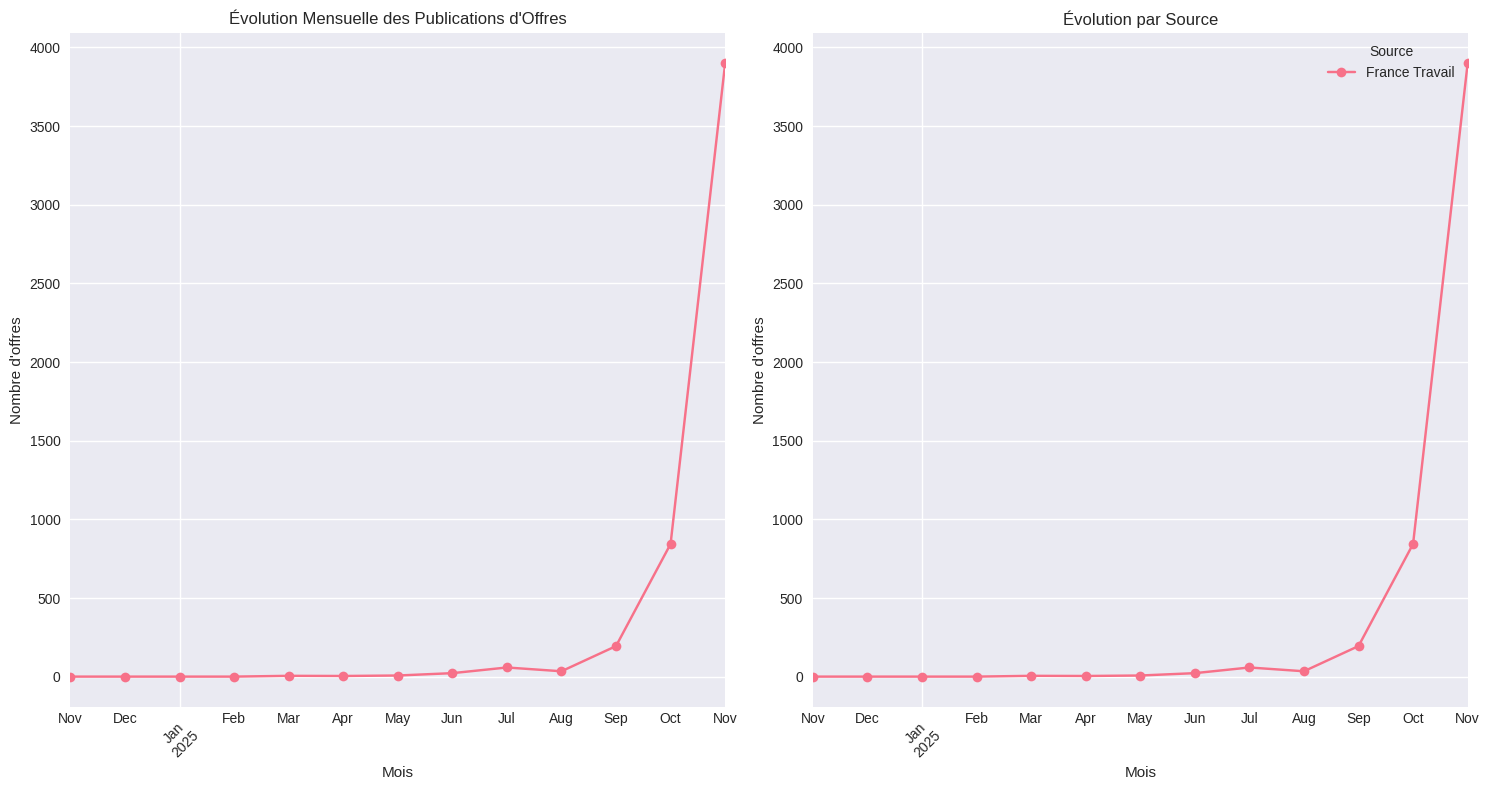


📈 Période couverte : 2024-11-14 11:32:38.124000+00:00 à 2025-11-26 00:01:32+00:00
📊 Nombre total de mois : 13


In [ ]:
print(" ANALYSE TEMPORELLE")
print("=" * 50)

if 'date_publication' in df_combined.columns:
    # Convertir en datetime
    df_combined['date_publication'] = pd.to_datetime(df_combined['date_publication'], errors='coerce')

    # Extraire le mois et l'année
    df_combined['mois_publication'] = df_combined['date_publication'].dt.to_period('M')

    # Évolution mensuelle
    evolution_mensuelle = df_combined['mois_publication'].value_counts().sort_index()

    plt.figure(figsize=(15, 8))

    plt.subplot(1, 2, 1)
    evolution_mensuelle.plot(kind='line', marker='o')
    plt.title('Évolution Mensuelle des Publications d\'Offres')
    plt.xlabel('Mois')
    plt.ylabel('Nombre d\'offres')
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    if 'source' in df_combined.columns:
        evolution_par_source = df_combined.groupby(['mois_publication', 'source']).size().unstack()
        evolution_par_source.plot(kind='line', marker='o', ax=plt.gca())
        plt.title('Évolution par Source')
        plt.xlabel('Mois')
        plt.ylabel('Nombre d\'offres')
        plt.xticks(rotation=45)
        plt.legend(title='Source')

    plt.tight_layout()
    plt.show()

    print(f"\n📈 Période couverte : {df_combined['date_publication'].min()} à {df_combined['date_publication'].max()}")
    print(f"📊 Nombre total de mois : {len(evolution_mensuelle)}")
else:
    print("❌ Colonne 'date_publication' non disponible")

## Analyse des entreprises

ANALYSE DES ENTREPRISES


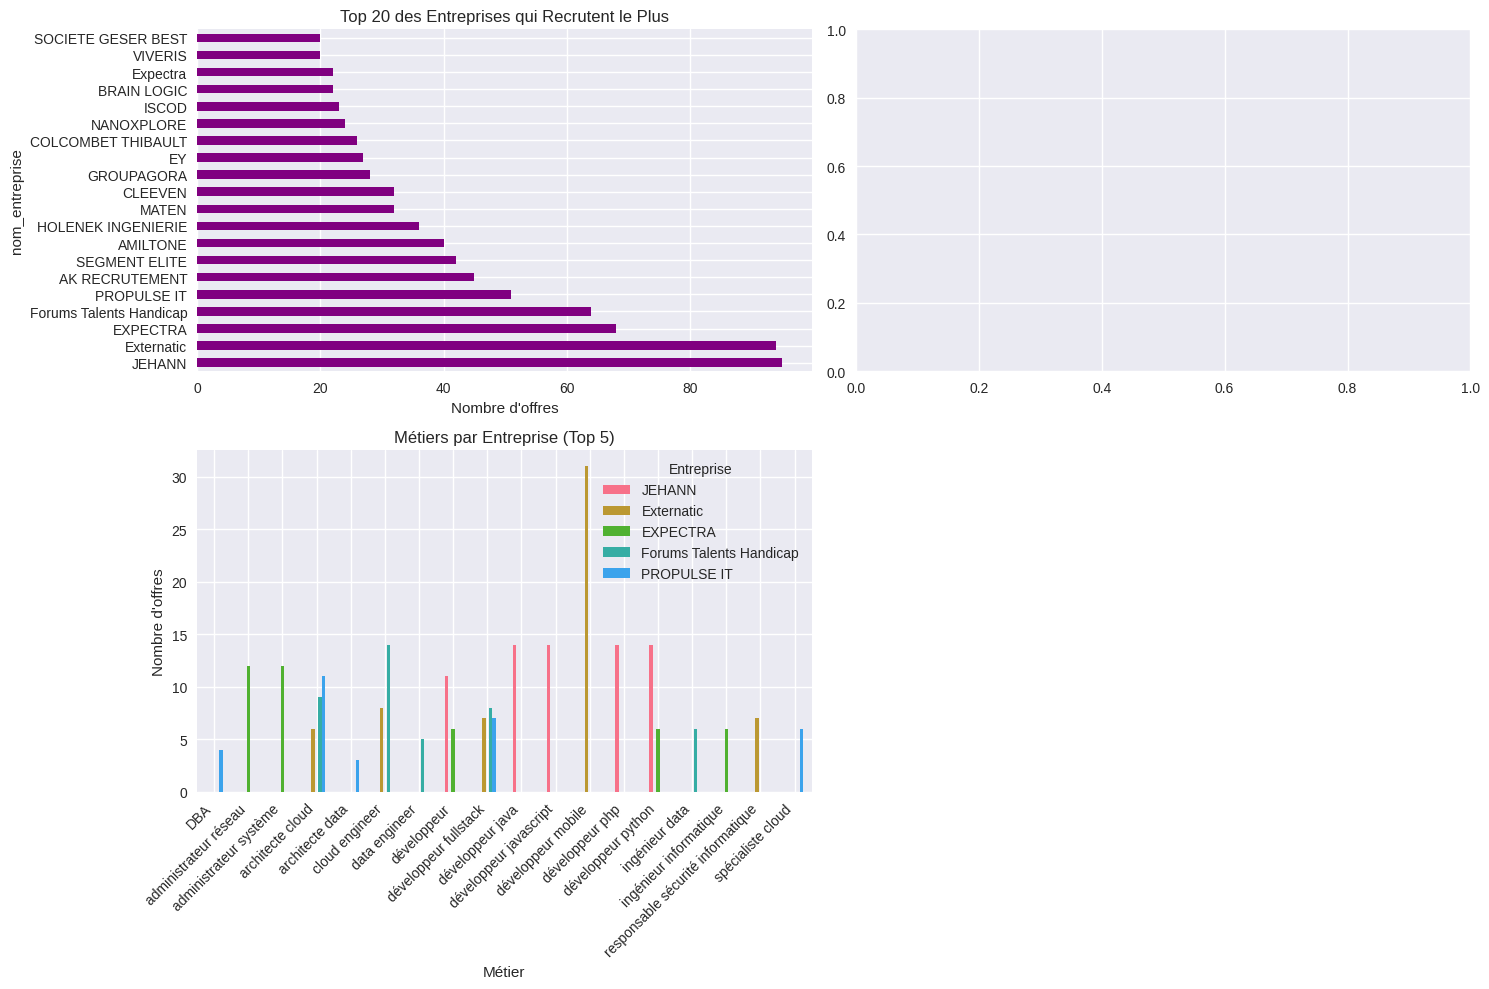


 Top 10 des entreprises recruteuses :
  1. JEHANN : 95 offres
  2. Externatic : 94 offres
  3. EXPECTRA : 68 offres
  4. Forums Talents Handicap : 64 offres
  5. PROPULSE IT : 51 offres
  6. AK RECRUTEMENT : 45 offres
  7. SEGMENT ELITE : 42 offres
  8. AMILTONE : 40 offres
  9. HOLENEK INGENIERIE : 36 offres
  10. MATEN : 32 offres

 Nombre total d'entreprises uniques : 1293
ANALYSE DES ENTREPRISES


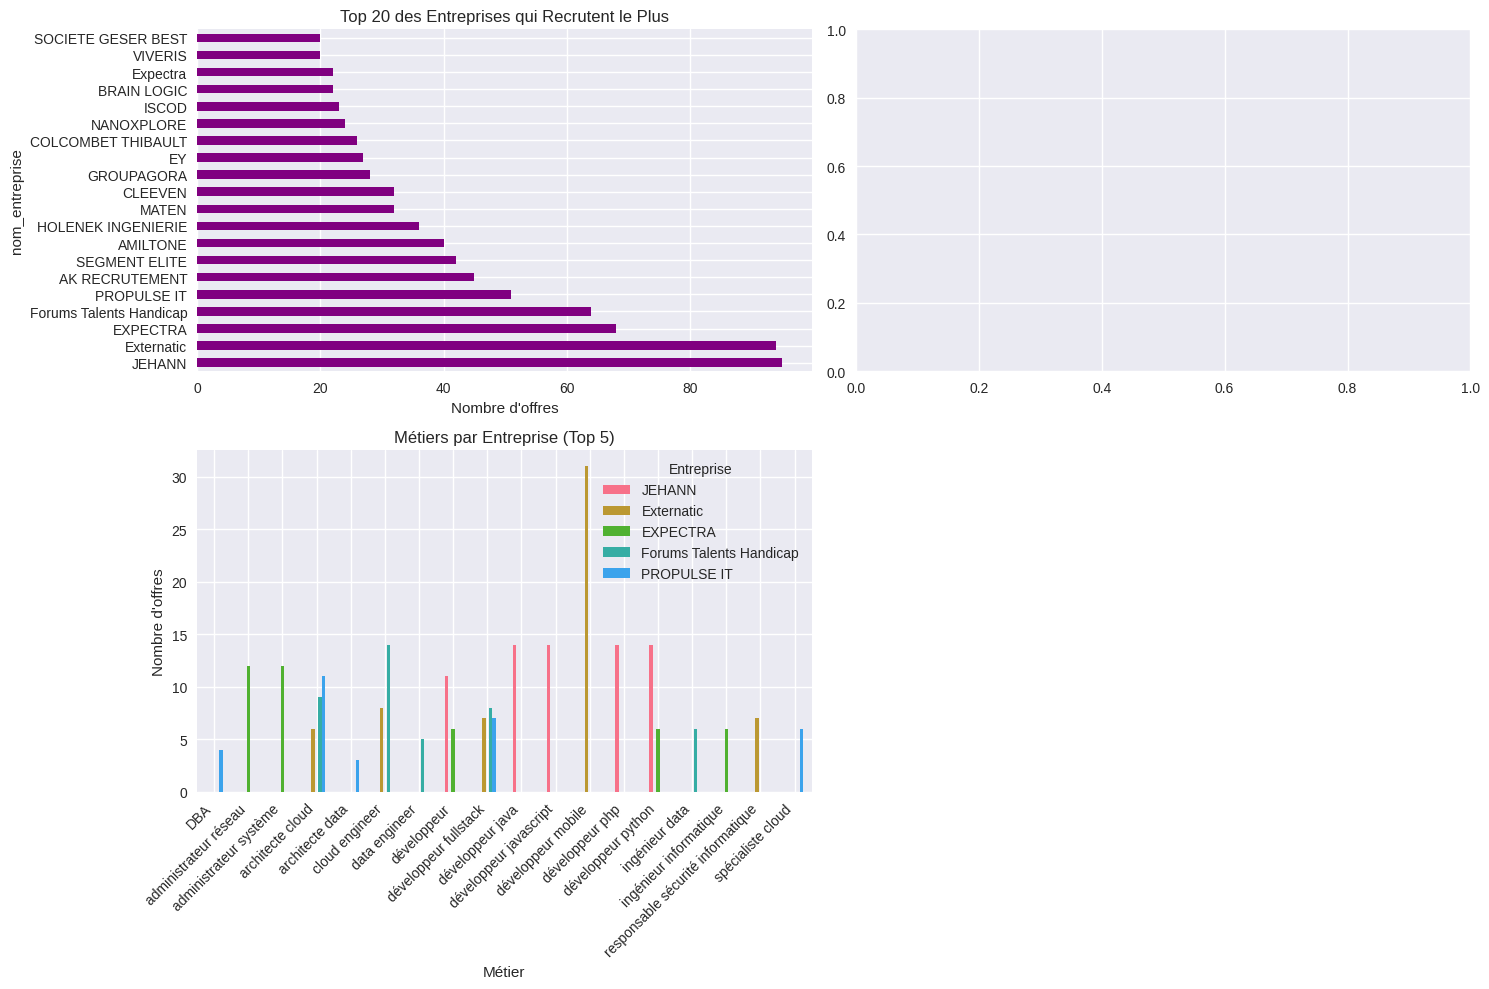


 Top 10 des entreprises recruteuses :
  1. JEHANN : 95 offres
  2. Externatic : 94 offres
  3. EXPECTRA : 68 offres
  4. Forums Talents Handicap : 64 offres
  5. PROPULSE IT : 51 offres
  6. AK RECRUTEMENT : 45 offres
  7. SEGMENT ELITE : 42 offres
  8. AMILTONE : 40 offres
  9. HOLENEK INGENIERIE : 36 offres
  10. MATEN : 32 offres

 Nombre total d'entreprises uniques : 1293


In [31]:
print("ANALYSE DES ENTREPRISES")
print("=" * 50)

if 'nom_entreprise' in df_combined.columns:
    # Top 20 des entreprises qui recrutent le plus
    entreprises_count = df_combined['nom_entreprise'].value_counts().head(20)

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    entreprises_count.plot(kind='barh', color='purple')
    plt.title('Top 20 des Entreprises qui Recrutent le Plus')
    plt.xlabel('Nombre d\'offres')

    # Répartition par taille d'entreprise (si disponible)
    plt.subplot(2, 2, 2)
    # Ici on pourrait ajouter une analyse par taille d'entreprise si disponible

    # Secteurs d'activité (approximatif par nom d'entreprise)
    plt.subplot(2, 2, 3)
    # Analyse des métiers par entreprise (top 5 entreprises)
    top_entreprises = entreprises_count.head(5).index
    metiers_par_entreprise = {}

    for entreprise in top_entreprises:
        entreprise_df = df_combined[df_combined['nom_entreprise'] == entreprise]
        metiers_par_entreprise[entreprise] = entreprise_df['metier_recherche'].value_counts().head(5)

    metiers_entreprise_df = pd.DataFrame(metiers_par_entreprise).fillna(0)
    metiers_entreprise_df.plot(kind='bar', ax=plt.gca())
    plt.title('Métiers par Entreprise (Top 5)')
    plt.xlabel('Métier')
    plt.ylabel('Nombre d\'offres')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Entreprise')

    plt.tight_layout()
    plt.show()

    print(f"\n Top 10 des entreprises recruteuses :")
    for i, (entreprise, count) in enumerate(entreprises_count.head(10).items(), 1):
        print(f"  {i}. {entreprise} : {count} offres")

    print(f"\n Nombre total d'entreprises uniques : {df_combined['nom_entreprise'].nunique()}")
else:
    print("❌ Colonne 'nom_entreprise' non disponible")

## Analyse comparative France Travail vs LinkedIn

ANALYSE COMPARATIVE FRANCE TRAVAIL VS LINKEDIN


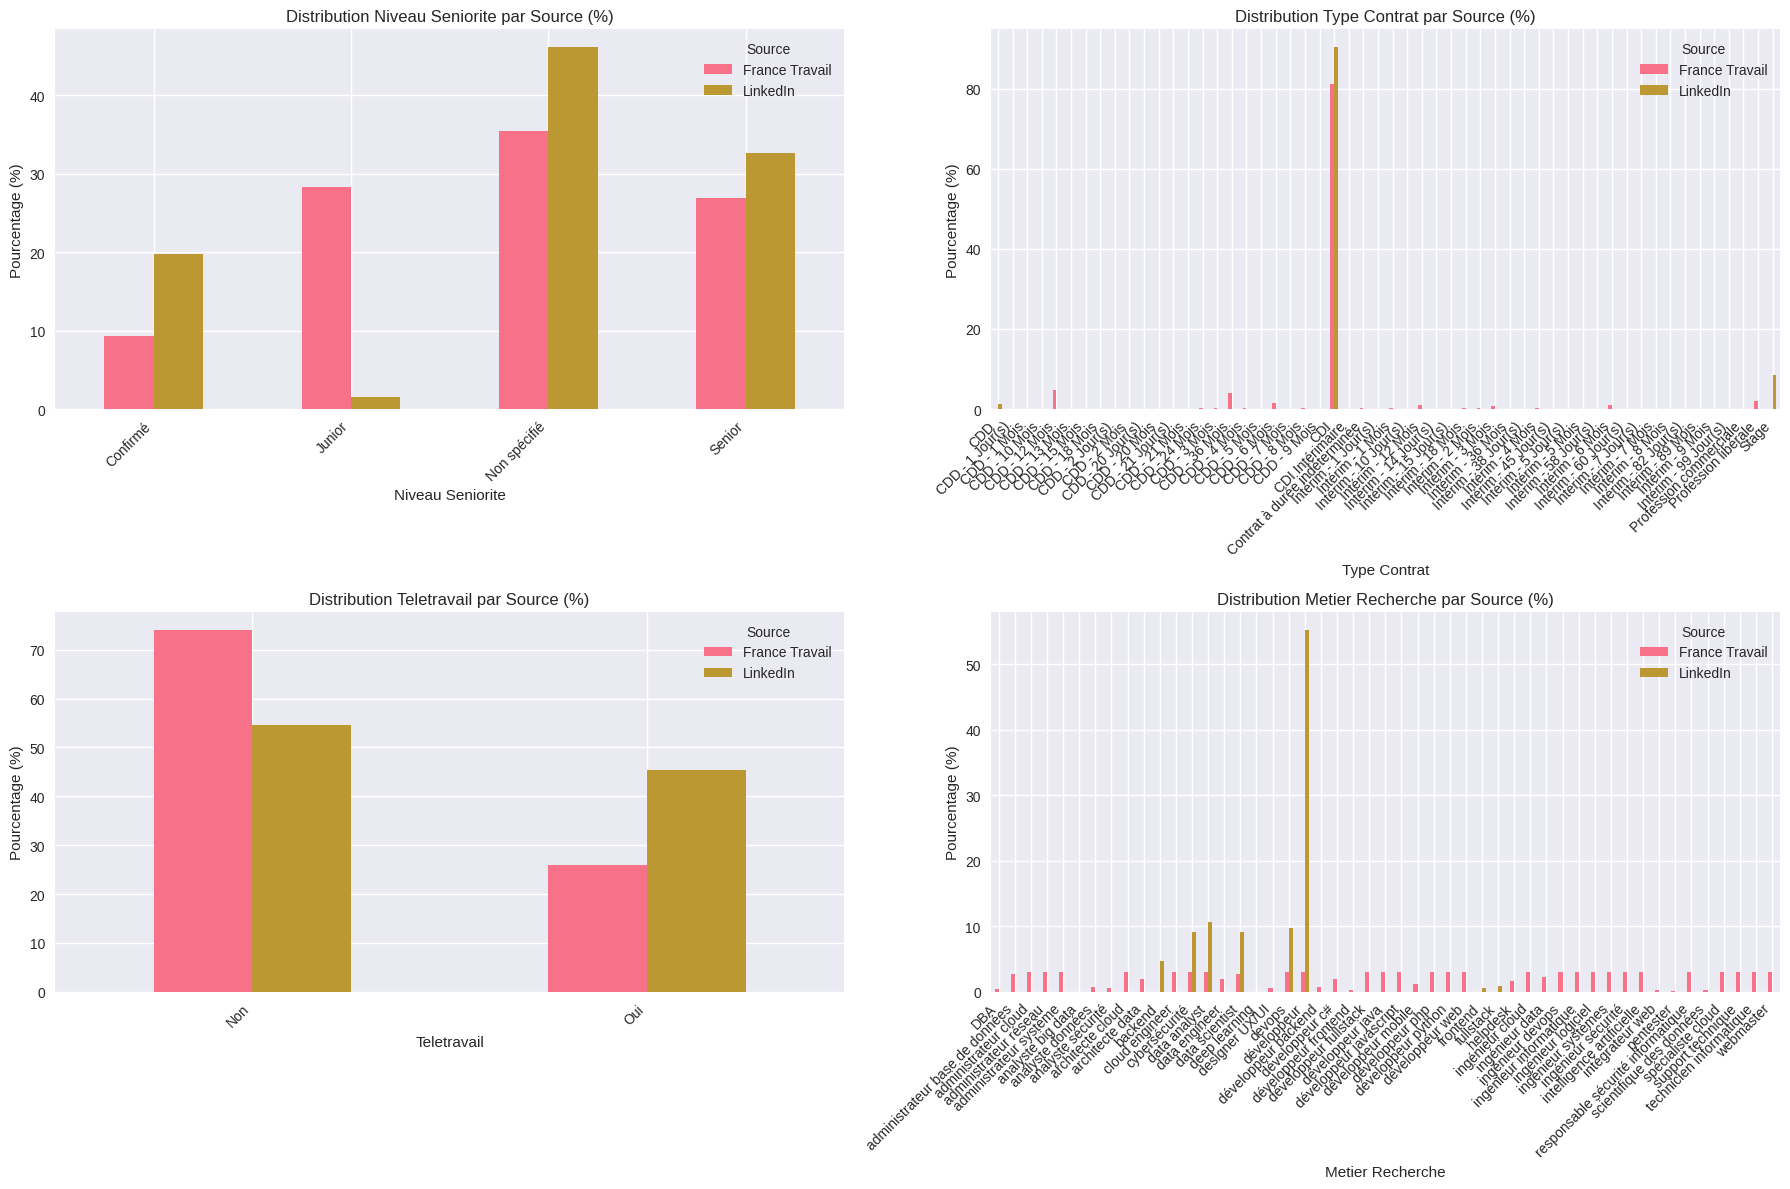


 STATISTIQUES COMPARATIVES :
------------------------------

 France Travail :
  • Nombre d'offres : 5077
  • Nombre d'entreprises uniques : 1095
  • Taux de télétravail : 26.0%
  • Salaire moyen min : 32572€
  • Salaire moyen max : 43098€

 LinkedIn :
  • Nombre d'offres : 319
  • Nombre d'entreprises uniques : 205
  • Taux de télétravail : 45.5%
  • Salaire moyen min : 47769€
  • Salaire moyen max : 61577€


In [32]:
print("ANALYSE COMPARATIVE FRANCE TRAVAIL VS LINKEDIN")
print("=" * 50)

if 'source' in df_combined.columns and len(df_combined['source'].unique()) > 1:
    comparative_stats = {}

    # Métriques de comparaison
    metrics = ['niveau_seniorite', 'type_contrat', 'teletravail', 'metier_recherche']

    plt.figure(figsize=(18, 12))

    for i, metric in enumerate(metrics, 1):
        if metric in df_combined.columns:
            plt.subplot(2, 2, i)
            cross_tab = pd.crosstab(df_combined[metric], df_combined['source'], normalize='columns') * 100
            cross_tab.plot(kind='bar', ax=plt.gca())
            plt.title(f'Distribution {metric.replace("_", " ").title()} par Source (%)')
            plt.xlabel(metric.replace('_', ' ').title())
            plt.ylabel('Pourcentage (%)')
            plt.xticks(rotation=45, ha='right')
            plt.legend(title='Source')

    plt.tight_layout()
    plt.show()

    # Statistiques numériques comparatives
    print("\n STATISTIQUES COMPARATIVES :")
    print("-" * 30)

    for source in df_combined['source'].unique():
        source_df = df_combined[df_combined['source'] == source]
        print(f"\n {source} :")
        print(f"  • Nombre d'offres : {len(source_df)}")
        print(f"  • Nombre d'entreprises uniques : {source_df['nom_entreprise'].nunique()}")
        print(f"  • Taux de télétravail : {(source_df['teletravail'] == 'Oui').sum()/len(source_df)*100:.1f}%")

        if 'salaire_min' in df_combined.columns:
            salaire_min_mean = source_df['salaire_min'].mean()
            salaire_max_mean = source_df['salaire_max'].mean()
            print(f"  • Salaire moyen min : {salaire_min_mean:.0f}€")
            print(f"  • Salaire moyen max : {salaire_max_mean:.0f}€")
else:
    print("❌ Données insuffisantes pour une analyse comparative")